In [33]:
import sys
print(sys.executable)

C:\Users\shahm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


# Predictive Maintenance of Radar Hardware

## Base Model: SVM vs Random Forest

This notebook develops the first predictive-maintenance model using a public proxy dataset.

The aim is to build the basic pipeline before applying the same approach to the TPS-77 radar maintenance record.

In [34]:
!pip -q install scikit-learn seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\shahm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


`Import libraries`

In [35]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

`Load the proxy dataset`

In [36]:
import os
import zipfile

zip_file_path = r'C:\Users\shahm\OneDrive\Desktop\Sem 7\fyp\online datasets\archive.zip'
extraction_path = 'dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}'")

'C:\Users\shahm\OneDrive\Desktop\Sem 7\fyp\online datasets\archive.zip' extracted to 'dataset'


In [37]:
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        print(os.path.join(root, file))

dataset\PdM_errors.csv
dataset\PdM_failures.csv
dataset\PdM_machines.csv
dataset\PdM_maint.csv
dataset\PdM_telemetry.csv


`Load the five datasets`

In [38]:
telemetry = pd.read_csv('dataset/PdM_telemetry.csv')
failures = pd.read_csv('dataset/PdM_failures.csv')
errors = pd.read_csv('dataset/PdM_errors.csv')
maintenance = pd.read_csv('dataset/PdM_maint.csv')
machines = pd.read_csv('dataset/PdM_machines.csv')

print("Telemetry:", telemetry.shape)
print("Failures:", failures.shape)
print("Errors:", errors.shape)
print("Maintenance:", maintenance.shape)
print("Machines:", machines.shape)

Telemetry: (876100, 6)
Failures: (761, 3)
Errors: (3919, 3)
Maintenance: (3286, 3)
Machines: (100, 3)


`Check the columns`

In [39]:
print("Telemetry")
print(telemetry.columns.tolist())

print("\nFailures")
print(failures.columns.tolist())

print("\nErrors")
print(errors.columns.tolist())

print("\nMaintenance")
print(maintenance.columns.tolist())

print("\nMachines")
print(machines.columns.tolist())

Telemetry
['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration']

Failures
['datetime', 'machineID', 'failure']

Errors
['datetime', 'machineID', 'errorID']

Maintenance
['datetime', 'machineID', 'comp']

Machines
['machineID', 'model', 'age']


`Look at the first few rows`

In [40]:
display(telemetry.head())
display(failures.head())
display(errors.head())
display(maintenance.head())
display(machines.head())

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


`Convert dates`

In [41]:
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])
failures["datetime"] = pd.to_datetime(failures["datetime"])
errors["datetime"] = pd.to_datetime(errors["datetime"])
maintenance["datetime"] = pd.to_datetime(maintenance["datetime"])

`Sort the data`

In [42]:
telemetry = telemetry.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

failures = failures.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

errors = errors.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

maintenance = maintenance.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

`Check missing values`

In [43]:
print("Telemetry")
print(telemetry.isnull().sum())

print("\nFailures")
print(failures.isnull().sum())

print("\nErrors")
print(errors.isnull().sum())

print("\nMaintenance")
print(maintenance.isnull().sum())

print("\nMachines")
print(machines.isnull().sum())

Telemetry
datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

Failures
datetime     0
machineID    0
failure      0
dtype: int64

Errors
datetime     0
machineID    0
errorID      0
dtype: int64

Maintenance
datetime     0
machineID    0
comp         0
dtype: int64

Machines
machineID    0
model        0
age          0
dtype: int64


`Basic dataset information`

In [44]:
print("Number of machines:", machines["machineID"].nunique())
print("Number of telemetry records:", len(telemetry))
print("Number of failures:", len(failures))
print("Number of errors:", len(errors))
print("Number of maintenance records:", len(maintenance))

Number of machines: 100
Number of telemetry records: 876100
Number of failures: 761
Number of errors: 3919
Number of maintenance records: 3286


`Failure types`

In [45]:
failures["failure"].value_counts()

failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

`Maintenance by component`

In [46]:
maintenance["comp"].value_counts()

comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64

`Failure history`

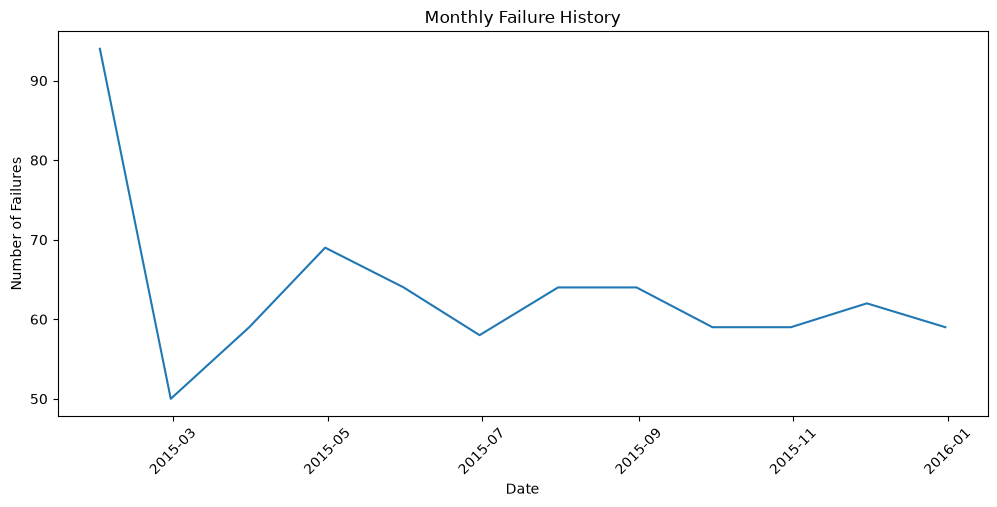

In [47]:
monthly_failures = (
    failures
    .set_index("datetime")
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_failures.index,
    monthly_failures.values
)

plt.title("Monthly Failure History")
plt.xlabel("Date")
plt.ylabel("Number of Failures")

plt.xticks(rotation=45)
plt.show()

`Create the modelling timeline`

In [48]:
timeline = telemetry[
    ["datetime", "machineID"]
].drop_duplicates().copy()

timeline = timeline.sort_values(
    ["machineID", "datetime"]
).reset_index(drop=True)

print("Timeline shape:", timeline.shape)
timeline.head()

Timeline shape: (876100, 2)


,datetime,machineID
0,2015-01-01 06:00:00,1
1,2015-01-01 07:00:00,1
2,2015-01-01 08:00:00,1
3,2015-01-01 09:00:00,1
4,2015-01-01 10:00:00,1


`Time since last maintenance`

In [49]:
maintenance_history = maintenance[
    ["datetime", "machineID"]
].copy()

maintenance_history = maintenance_history.rename(
    columns={"datetime": "maintenance_time"}
)

timeline = pd.merge_asof(
    timeline.sort_values("datetime"),
    maintenance_history.sort_values("maintenance_time"),
    left_on="datetime",
    right_on="maintenance_time",
    by="machineID",
    direction="backward"
)

timeline["time_since_last_maintenance"] = (
    timeline["datetime"] -
    timeline["maintenance_time"]
).dt.total_seconds() / 86400

In [50]:
timeline["time_since_last_maintenance"] = (
    timeline["time_since_last_maintenance"]
    .fillna(365)
)
#For machines where there isn't a previous maintenance record

`Time since last failure`

In [51]:
failure_history = failures[
    ["datetime", "machineID"]
].copy()

failure_history = failure_history.rename(
    columns={"datetime": "failure_time"}
)

timeline = pd.merge_asof(
    timeline.sort_values("datetime"),
    failure_history.sort_values("failure_time"),
    left_on="datetime",
    right_on="failure_time",
    by="machineID",
    direction="backward"
)

timeline["time_since_last_failure"] = (
    timeline["datetime"] -
    timeline["failure_time"]
).dt.total_seconds() / 86400

timeline["time_since_last_failure"] = (
    timeline["time_since_last_failure"]
    .fillna(365)
)

`Cumulative failure count`

In [52]:
failure_times = (
    failures[
        ["machineID", "datetime"]
    ]
    .sort_values(["machineID", "datetime"])
)

timeline["cumulative_failure_count"] = 0

for machine_id, group in failure_times.groupby("machineID"):

    dates = group["datetime"].values

    mask = timeline["machineID"].eq(machine_id)

    timeline.loc[mask, "cumulative_failure_count"] = np.searchsorted(
        dates,
        timeline.loc[mask, "datetime"].values,
        side="left"
    )

In [53]:
timeline[
    [
        "datetime",
        "machineID",
        "cumulative_failure_count"
    ]
].head(20)

,datetime,machineID,cumulative_failure_count
0,2015-01-01 06:00:00,1,0
1,2015-01-01 06:00:00,50,0
2,2015-01-01 06:00:00,60,0
3,2015-01-01 06:00:00,31,0
4,2015-01-01 06:00:00,78,0
5,2015-01-01 06:00:00,14,0
6,2015-01-01 06:00:00,48,0
7,2015-01-01 06:00:00,40,0
8,2015-01-01 06:00:00,97,0
9,2015-01-01 06:00:00,61,0


`Running failure rate`

In [54]:
first_observation = (
    timeline.groupby("machineID")["datetime"]
    .transform("min")
)

days_observed = (
    timeline["datetime"] - first_observation
).dt.total_seconds() / 86400

days_observed = days_observed.clip(lower=1)

timeline["running_failure_rate"] = (
    timeline["cumulative_failure_count"] /
    days_observed
)

`Interval between successive failures`

In [55]:
failure_intervals = (
    failures
    .sort_values(["machineID", "datetime"])
    .copy()
)

failure_intervals["failure_interval_days"] = (
    failure_intervals
    .groupby("machineID")["datetime"]
    .diff()
    .dt.total_seconds() / 86400
)

In [56]:
failure_intervals.head(10)

,datetime,machineID,failure,failure_interval_days
0,2015-01-05 06:00:00,1,comp4,NaN
1,2015-03-06 06:00:00,1,comp1,60.0
2,2015-04-20 06:00:00,1,comp2,45.0
3,2015-06-19 06:00:00,1,comp4,60.0
4,2015-09-02 06:00:00,1,comp4,75.0
5,2015-10-17 06:00:00,1,comp2,45.0
6,2015-12-16 06:00:00,1,comp4,60.0
7,2015-03-19 06:00:00,2,comp1,NaN
8,2015-03-19 06:00:00,2,comp2,0.0
9,2015-04-18 06:00:00,2,comp2,30.0


Adding the latest known failure interval to the timeline

In [57]:
interval_history = failure_intervals[
    [
        "machineID",
        "datetime",
        "failure_interval_days"
    ]
].dropna()

interval_history = interval_history.rename(
    columns={"datetime": "interval_time"}
)

timeline = pd.merge_asof(
    timeline.sort_values("datetime"),
    interval_history.sort_values("interval_time"),
    left_on="datetime",
    right_on="interval_time",
    by="machineID",
    direction="backward"
)

timeline["failure_interval_days"] = (
    timeline["failure_interval_days"]
    .fillna(0)
)

`Check all four main features`

In [58]:
feature_columns = [
    "time_since_last_maintenance",
    "time_since_last_failure",
    "cumulative_failure_count",
    "running_failure_rate",
    "failure_interval_days"
]

timeline[feature_columns].describe()
#4 are the core PDD time-based features
#time_since_last_failure is useful for the event-history representation and helps us construct the predictive timeline

,time_since_last_maintenance,time_since_last_failure,cumulative_failure_count,running_failure_rate,failure_interval_days
count,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,10.984237,71.661970,3.976375,0.024086,33.198864
std,13.422472,104.440888,3.150220,0.030399,38.998379
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.250000,12.958333,2.000000,0.012161,0.000000
50%,8.541667,30.791667,3.000000,0.021173,30.000000
75%,12.875000,67.416667,6.000000,0.029548,45.000000
max,169.958333,365.000000,19.000000,2.000000,270.000000


`Creating the future-failure target`

In [59]:
future_window = pd.Timedelta(hours=24)

In [60]:
future_failures = failures[
    ["machineID", "datetime"]
].sort_values(
    ["machineID", "datetime"]
).copy()

future_failures = future_failures.rename(
    columns={"datetime": "future_failure_time"}
)

timeline = pd.merge_asof(
    timeline.sort_values("datetime"),
    future_failures.sort_values("future_failure_time"),
    left_on="datetime",
    right_on="future_failure_time",
    by="machineID",
    direction="forward",
    allow_exact_matches=False
)

`Calculate time until next failure`

In [61]:
timeline["time_to_next_failure"] = (
    timeline["future_failure_time"] -
    timeline["datetime"]
)

In [62]:
timeline[
    [
        "datetime",
        "machineID",
        "future_failure_time",
        "time_to_next_failure"
    ]
].head(20)

,datetime,machineID,future_failure_time,time_to_next_failure
0,2015-01-01 06:00:00,1,2015-01-05 06:00:00,4 days 00:00:00
1,2015-01-01 06:00:00,50,2015-01-30 06:00:00,29 days 00:00:00
2,2015-01-01 06:00:00,60,2015-01-30 06:00:00,29 days 00:00:00
3,2015-01-01 06:00:00,31,2015-03-23 06:00:00,81 days 00:00:00
4,2015-01-01 06:00:00,78,2015-02-05 06:00:00,35 days 00:00:00
5,2015-01-01 06:00:00,14,2015-01-31 06:00:00,30 days 00:00:00
6,2015-01-01 06:00:00,48,2015-01-11 06:00:00,10 days 00:00:00
7,2015-01-01 06:00:00,40,2015-01-04 06:00:00,3 days 00:00:00
8,2015-01-01 06:00:00,97,2015-01-24 06:00:00,23 days 00:00:00
9,2015-01-01 06:00:00,61,2015-02-27 06:00:00,57 days 00:00:00


`Create the classification target`

In [63]:
timeline["maintenance_needed"] = (
    timeline["time_to_next_failure"] <= future_window
).astype(int)

In [64]:
#0 → no failure expected within next 24 hours
#1 → failure expected within next 24 hours

In [65]:
print(timeline["maintenance_needed"].value_counts())

print(timeline["maintenance_needed"].value_counts(normalize=True))

maintenance_needed
0    858916
1     17184
Name: count, dtype: int64
maintenance_needed
0    0.980386
1    0.019614
Name: proportion, dtype: float64


`Creating the final modelling dataframe`

In [66]:
model_data = timeline[
    [
        "datetime",
        "machineID",
        "maintenance_needed"
    ] + feature_columns
].copy()

model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)

model_data = model_data.dropna().reset_index(drop=True)

print("Final modelling data:", model_data.shape)
model_data.head()

Final modelling data: (876100, 8)


,datetime,machineID,maintenance_needed,time_since_last_maintenance,time_since_last_failure,cumulative_failure_count,running_failure_rate,failure_interval_days
0,2015-01-01 06:00:00,1,0,19.0,365.0,0,0.0,0.0
1,2015-01-01 06:00:00,50,0,64.0,365.0,0,0.0,0.0
2,2015-01-01 06:00:00,60,0,94.0,365.0,0,0.0,0.0
3,2015-01-01 06:00:00,31,0,94.0,365.0,0,0.0,0.0
4,2015-01-01 06:00:00,78,0,34.0,365.0,0,0.0,0.0


In [67]:
model_data[feature_columns].describe()

,time_since_last_maintenance,time_since_last_failure,cumulative_failure_count,running_failure_rate,failure_interval_days
count,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,10.984237,71.661970,3.976375,0.024086,33.198864
std,13.422472,104.440888,3.150220,0.030399,38.998379
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.250000,12.958333,2.000000,0.012161,0.000000
50%,8.541667,30.791667,3.000000,0.021173,30.000000
75%,12.875000,67.416667,6.000000,0.029548,45.000000
max,169.958333,365.000000,19.000000,2.000000,270.000000


In [68]:
print(
    model_data["maintenance_needed"].value_counts()
)

maintenance_needed
0    858916
1     17184
Name: count, dtype: int64


`Check the 24-hour target properly`

In [69]:
for hours in [24, 48, 72]:
    window = pd.Timedelta(hours=hours)

    positive = (
        timeline["time_to_next_failure"] <= window
    ).sum()

    total = len(timeline)

    print(
        f"{hours} hours: "
        f"{positive:,} positive cases "
        f"({positive / total:.2%})"
    )

24 hours: 17,184 positive cases (1.96%)
48 hours: 33,960 positive cases (3.88%)
72 hours: 50,736 positive cases (5.79%)


`Keep the 24-hour target`

In [70]:
future_window_hours = 24
future_window = pd.Timedelta(hours=future_window_hours)

timeline["maintenance_needed"] = (
    timeline["time_to_next_failure"] <= future_window
).astype(int)

In [71]:
print(timeline["maintenance_needed"].value_counts())
print()
print(timeline["maintenance_needed"].value_counts(normalize=True))

maintenance_needed
0    858916
1     17184
Name: count, dtype: int64

maintenance_needed
0    0.980386
1    0.019614
Name: proportion, dtype: float64


`Final modelling data`

In [72]:
feature_columns = [
    "time_since_last_maintenance",
    "time_since_last_failure",
    "cumulative_failure_count",
    "running_failure_rate",
    "failure_interval_days"
]

model_data = timeline[
    [
        "datetime",
        "machineID",
        "maintenance_needed"
    ] + feature_columns
].copy()

model_data = model_data.replace(
    [np.inf, -np.inf],
    np.nan
)

model_data = model_data.dropna().reset_index(drop=True)

print("Final modelling data:", model_data.shape)

Final modelling data: (876100, 8)


`Check the target again`

In [73]:
print(
    model_data["maintenance_needed"].value_counts()
)

print()

print(
    model_data["maintenance_needed"]
    .value_counts(normalize=True)
)

maintenance_needed
0    858916
1     17184
Name: count, dtype: int64

maintenance_needed
0    0.980386
1    0.019614
Name: proportion, dtype: float64


`chronological train/test split`

In [74]:
model_data = model_data.sort_values(
    "datetime"
).reset_index(drop=True)

split_point = int(len(model_data) * 0.80)

train_data = model_data.iloc[:split_point].copy()
test_data = model_data.iloc[split_point:].copy()

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

print("\nTraining period:")
print(train_data["datetime"].min(), "to", train_data["datetime"].max())

print("\nTesting period:")
print(test_data["datetime"].min(), "to", test_data["datetime"].max())

Training data: (700880, 8)
Testing data: (175220, 8)

Training period:
2015-01-01 06:00:00 to 2015-10-20 06:00:00

Testing period:
2015-10-20 06:00:00 to 2016-01-01 06:00:00


`Prepare X and y`

In [75]:
X_train = train_data[feature_columns]
y_train = train_data["maintenance_needed"]

X_test = test_data[feature_columns]
y_test = test_data["maintenance_needed"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

X_train: (700880, 5)
X_test : (175220, 5)

Training classes:
maintenance_needed
0    686837
1     14043
Name: count, dtype: int64

Testing classes:
maintenance_needed
0    172079
1      3141
Name: count, dtype: int64


`Checking the split`

In [76]:
print("Training positive rate:",
      y_train.mean())

print("Testing positive rate:",
      y_test.mean())


Training positive rate: 0.02003624015523342
Testing positive rate: 0.01792603584065746


`Train SVM`

In [77]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [78]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=5000
        )
    )
])

svm_model.fit(
    X_train,
    y_train
)

print("SVM training completed.")

SVM training completed.


`Train Random Forest`

In [79]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


`Generate predictions`

In [80]:
svm_pred = svm_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

svm_score = svm_model.decision_function(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


`Evaluation function`

In [81]:
def evaluate_model(name, y_true, predictions, probabilities):

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

`Compare the models`

In [82]:
results = pd.DataFrame([
    evaluate_model(
        "SVM",
        y_test,
        svm_pred,
        svm_score
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM,0.5923,0.0363,0.8520,0.0697,0.7945
1,Random Forest,0.9546,0.2541,0.7924,0.3848,0.9748


In [83]:
#Random Forest is clearly the stronger base model.

`Confusion matrices`

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

`SVM confusion matrix`

SVM Confusion Matrix
[[101108  70971]
 [   465   2676]]


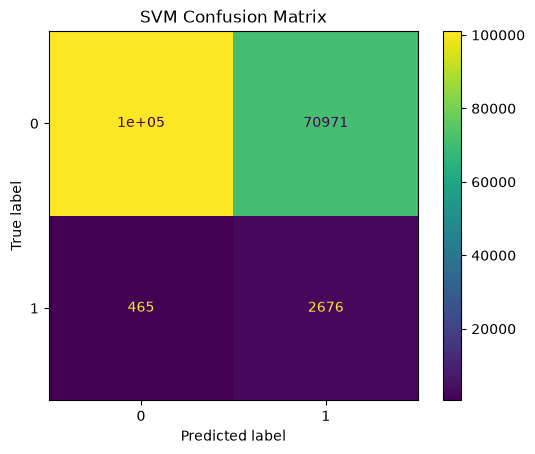

In [85]:
svm_cm = confusion_matrix(
    y_test,
    svm_pred
)

print("SVM Confusion Matrix")
print(svm_cm)

ConfusionMatrixDisplay(
    confusion_matrix=svm_cm
).plot()

plt.title("SVM Confusion Matrix")
plt.show()

`Random Forest confusion matrix`

Random Forest Confusion Matrix
[[164774   7305]
 [   652   2489]]


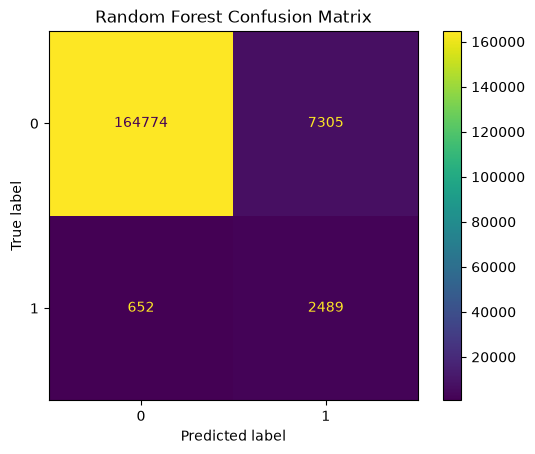

In [86]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("Random Forest Confusion Matrix")
print(rf_cm)

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

`Detailed classification report`

In [87]:
print("SVM Classification Report")
print(
    classification_report(
        y_test,
        svm_pred,
        digits=4,
        zero_division=0
    )
)

print("\nRandom Forest Classification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        digits=4,
        zero_division=0
    )
)

SVM Classification Report
              precision    recall  f1-score   support

           0     0.9954    0.5876    0.7390    172079
           1     0.0363    0.8520    0.0697      3141

    accuracy                         0.5923    175220
   macro avg     0.5159    0.7198    0.4043    175220
weighted avg     0.9782    0.5923    0.7270    175220


Random Forest Classification Report
              precision    recall  f1-score   support

           0     0.9961    0.9575    0.9764    172079
           1     0.2541    0.7924    0.3848      3141

    accuracy                         0.9546    175220
   macro avg     0.6251    0.8750    0.6806    175220
weighted avg     0.9828    0.9546    0.9658    175220



`Compare the models visually`

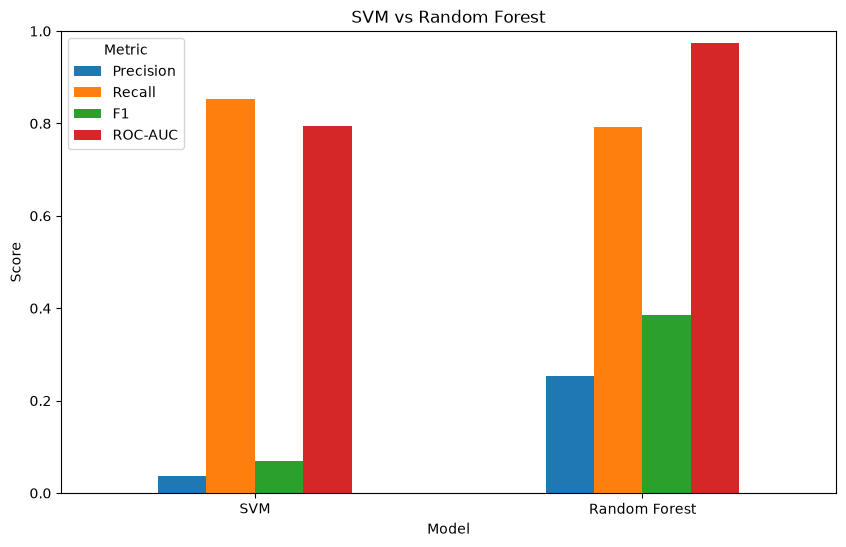

In [88]:
metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

comparison = results.set_index("Model")[metrics]

comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("SVM vs Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

`Random Forest feature importance`

In [89]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,time_since_last_maintenance,0.824633
1,time_since_last_failure,0.136644
2,running_failure_rate,0.025431
3,cumulative_failure_count,0.007793
4,failure_interval_days,0.005499


`Plot feature importance`

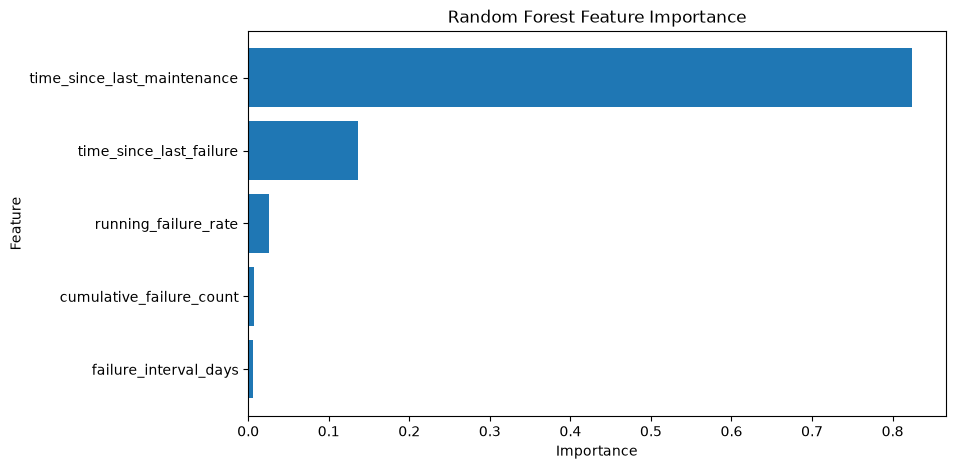

In [90]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.show()

In [91]:
#The model is relying overwhelmingly on:

#time_since_last_maintenance — ~0.82
#time_since_last_failure — ~0.14
#running_failure_rate — ~0.03
#cumulative_failure_count — very small
#failure_interval_days — very small

#So the model is mainly learning the relationship between maintenance recency and upcoming failure risk.

*`ROC curves`*

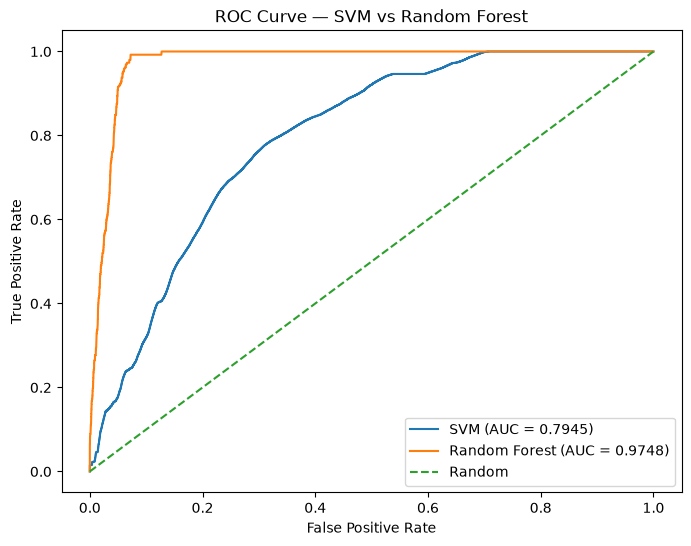

In [92]:
from sklearn.metrics import roc_curve

svm_fpr, svm_tpr, _ = roc_curve(
    y_test,
    svm_score
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM (AUC = {roc_auc_score(y_test, svm_score):.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM vs Random Forest")
plt.legend()
plt.show()

`Permutation importance`

In [93]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

permutation_importance_df

,Feature,Importance
0,time_since_last_maintenance,0.350229
1,time_since_last_failure,0.031095
4,failure_interval_days,0.002701
3,running_failure_rate,-0.016443
2,cumulative_failure_count,-0.035917


`Plotting it`

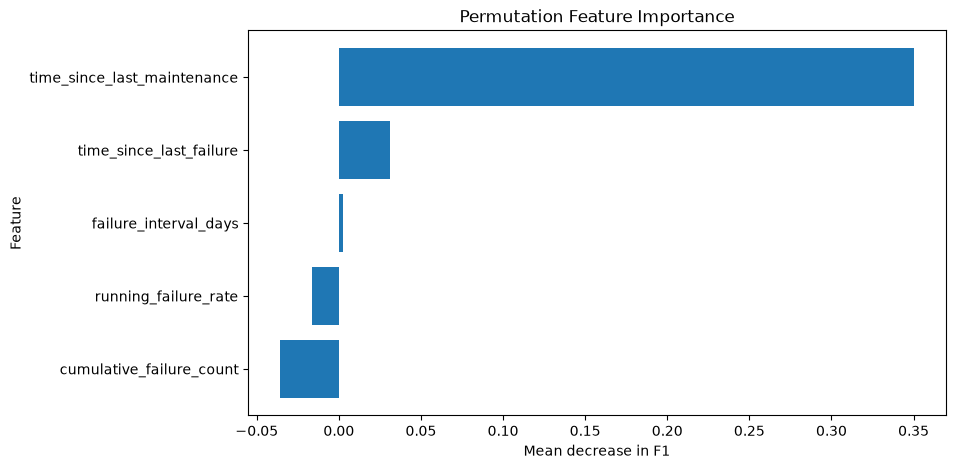

In [94]:
plt.figure(figsize=(9, 5))

plt.barh(
    permutation_importance_df["Feature"],
    permutation_importance_df["Importance"]
)

plt.xlabel("Mean decrease in F1")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()
plt.show()

`Save the baseline results`

In [95]:
results.to_csv(
    "model_comparison_baseline.csv",
    index=False
)

feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

permutation_importance_df.to_csv(
    "permutation_feature_importance.csv",
    index=False
)

print("Baseline results saved.")

Baseline results saved.


`Saving the trained models`

In [96]:
import joblib

joblib.dump(
    svm_model,
    "svm_predictive_maintenance.pkl"
)

joblib.dump(
    rf_model,
    "random_forest_predictive_maintenance.pkl"
)

print("Models saved.")

Models saved.


In [97]:
import os
print(os.getcwd())

c:\Users\shahm\OneDrive\Desktop\Sem 7\fyp\saad
